# **SAIA 2163 - NATURAL LANGUAGE PROCESSING - PROJECT**
**TEAM NAME:** Project Saf

**TEAM MEMBERS:**

CHENG HAO WEN (A24AI0022)

MUHAMMAD SAFRUL ROSLI (A24AI0064)

JAGADESH (A24AI0035)

**SECTION:** 03

**LECTURER:** ASSOC. PROF. DR. SITI SOPHIAYATI YUHANIZ



# News Article Categorizer — Checkpoint 1


# Import Required Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Dataset Download and Loading (20 Newsgroups)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("crawford/20-newsgroups")
print(path)

100%|██████████| 25.7M/25.7M [00:02<00:00, 10.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/crawford/20-newsgroups/versions/1


# Data Preprocessing and DataFrame Construction

In [ ]:
data = []

for file in os.listdir(path):
    if not file.endswith(".txt"):
        continue

    label = file.replace(".txt", "")
    file_path = os.path.join(path, file)

    with open(file_path, encoding="latin1") as f:
        content = f.read()

    articles = content.split("From:")

    for article in articles:
        article = article.strip()

        if len(article.split()) < 20:
            continue

        data.append([article, label])

df = pd.DataFrame(data, columns=["text", "label"])

print(df.shape)
df.head()

(39259, 2)


,text,label
0,bed@intacc.uucp (Deb Waddington)\nSubject: INF...,sci.med
1,mcdonald@aries.scs.uiuc.edu (J. D. McDonald)\n...,sci.med
2,fulk@cs.rochester.edu (Mark Fulk)\nSubject: Re...,sci.med
3,Lawrence Curcio <lc2b+@andrew.cmu.edu>\nSubjec...,sci.med
4,uabdpo.dpo.uab.edu!gila005 (Stephen Holland)\n...,sci.med


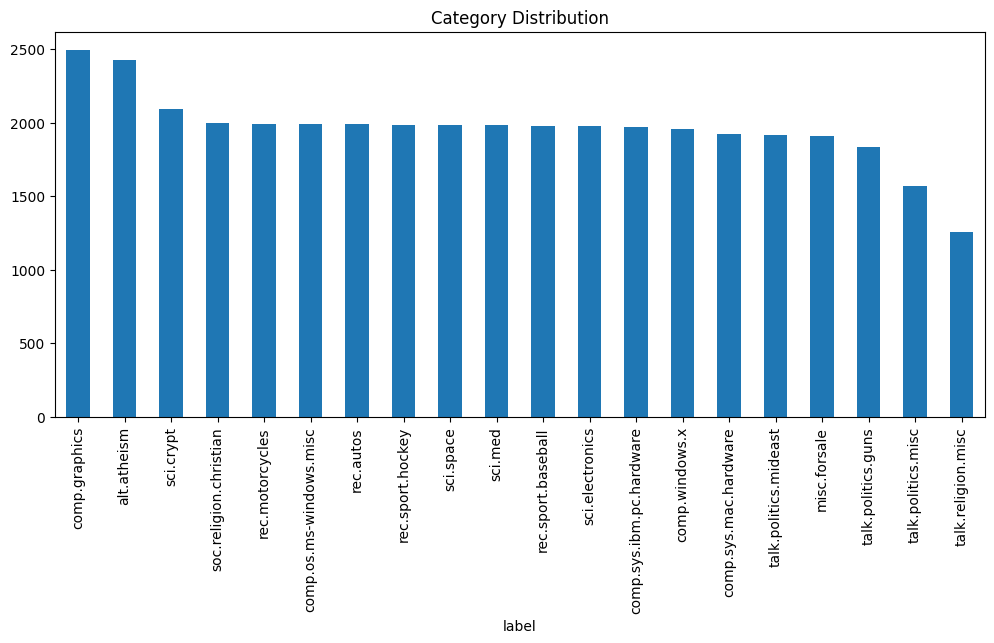

In [ ]:
df["label"].value_counts().plot(kind="bar", figsize=(12,5))
plt.title("Category Distribution")
plt.xticks(rotation=90)
plt.show()

# Text Cleaning and NLP Preprocessing

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

print("Preprocessing done")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Preprocessing done


# Train-Test Split

In [ ]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 31407
Test size: 7852


# Feature Extraction Using TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF:", X_train_tfidf.shape)

TF-IDF: (31407, 5000)


# Feature Extraction Using Bag of Words (BoW)

In [ ]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("BoW:", X_train_bow.shape)

BoW: (31407, 5000)


# Model Training (Naive Bayes & Logistic Regression - TF-IDF)

In [ ]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# Model Training (Naive Bayes & Logistic Regression - BoW)

In [ ]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
pred_nb_bow = nb_bow.predict(X_test_bow)

lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
pred_lr_bow = lr_bow.predict(X_test_bow)

# Model Evaluation Results

In [ ]:
def evaluate(name, y_true, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate("TF-IDF + NB", y_test, pred_nb_tfidf)
evaluate("TF-IDF + LR", y_test, pred_lr_tfidf)
evaluate("BoW + NB", y_test, pred_nb_bow)
evaluate("BoW + LR", y_test, pred_lr_bow)


 TF-IDF + NB
Accuracy: 0.9298267957208355
                          precision    recall  f1-score   support

             alt.atheism       0.87      0.94      0.90       486
           comp.graphics       0.86      0.94      0.90       499
 comp.os.ms-windows.misc       0.92      0.92      0.92       398
comp.sys.ibm.pc.hardware       0.83      0.90      0.86       395
   comp.sys.mac.hardware       0.97      0.93      0.95       385
          comp.windows.x       0.91      0.92      0.92       392
            misc.forsale       0.94      0.90      0.92       382
               rec.autos       0.97      0.96      0.97       398
         rec.motorcycles       0.97      0.98      0.98       399
      rec.sport.baseball       0.98      0.99      0.98       396
        rec.sport.hockey       0.99      0.99      0.99       398
               sci.crypt       0.96      0.96      0.96       418
         sci.electronics       0.95      0.90      0.93       396
                 sci.med       0

# Performance Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model": ["TF-IDF + NB", "TF-IDF + LR", "BoW + NB", "BoW + LR"],

    "Accuracy": [
        accuracy_score(y_test, pred_nb_tfidf),
        accuracy_score(y_test, pred_lr_tfidf),
        accuracy_score(y_test, pred_nb_bow),
        accuracy_score(y_test, pred_lr_bow)
    ],

    "Precision": [
        precision_score(y_test, pred_nb_tfidf, average="weighted"),
        precision_score(y_test, pred_lr_tfidf, average="weighted"),
        precision_score(y_test, pred_nb_bow, average="weighted"),
        precision_score(y_test, pred_lr_bow, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, pred_nb_tfidf, average="weighted"),
        recall_score(y_test, pred_lr_tfidf, average="weighted"),
        recall_score(y_test, pred_nb_bow, average="weighted"),
        recall_score(y_test, pred_lr_bow, average="weighted")
    ],

    "F1-Score": [
        f1_score(y_test, pred_nb_tfidf, average="weighted"),
        f1_score(y_test, pred_lr_tfidf, average="weighted"),
        f1_score(y_test, pred_nb_bow, average="weighted"),
        f1_score(y_test, pred_lr_bow, average="weighted")
    ]
})

from IPython.display import display
display(results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + NB,0.9298,0.9327,0.9298,0.9287
1,TF-IDF + LR,0.9907,0.9908,0.9907,0.9907
2,BoW + NB,0.9386,0.9392,0.9386,0.9384
3,BoW + LR,0.9972,0.9972,0.9972,0.9972


# Confusion Matrix

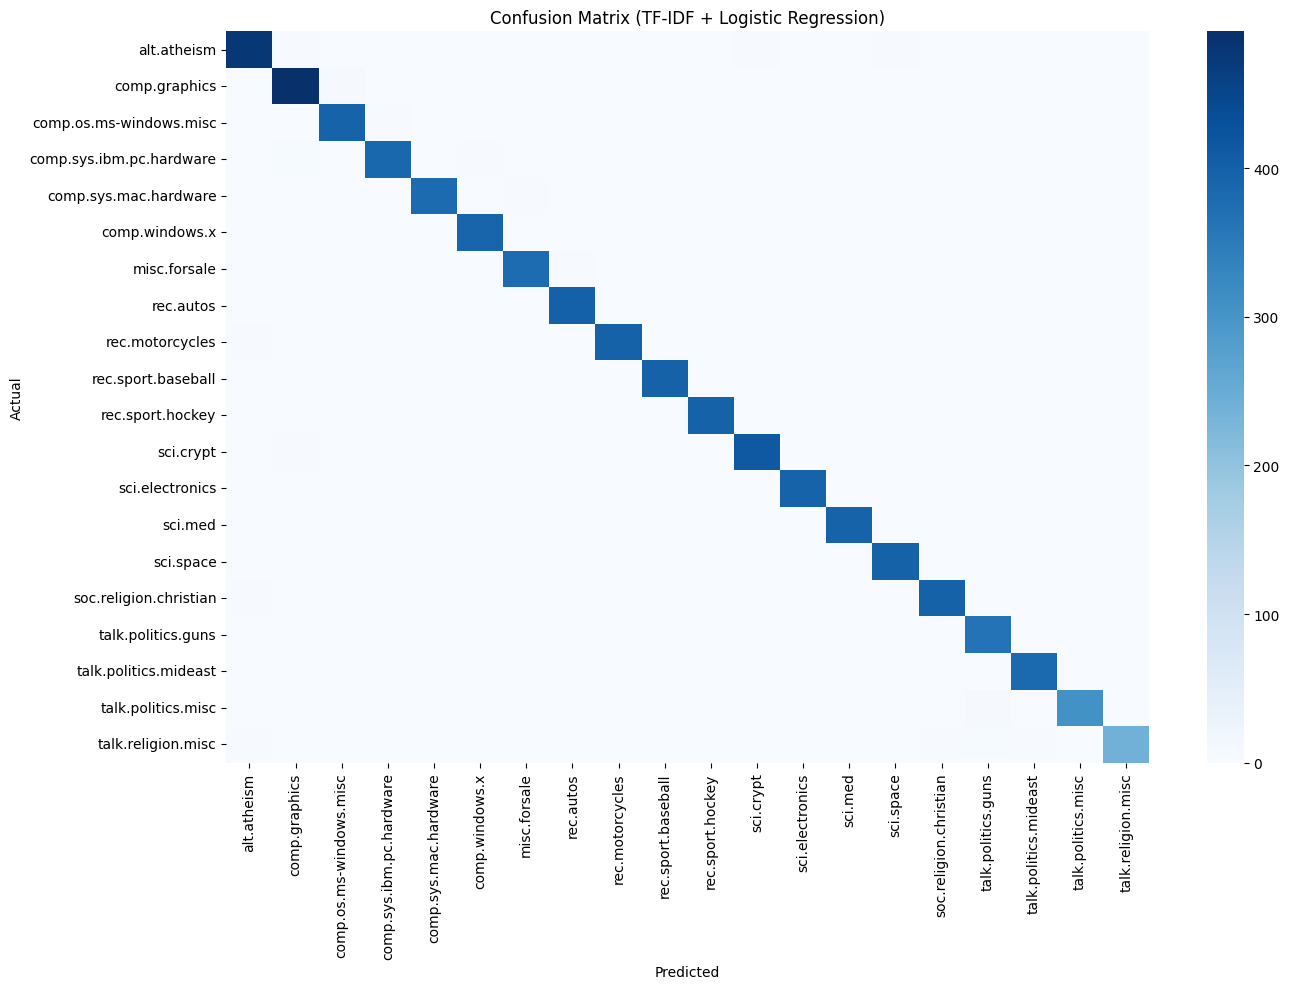

In [ ]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, pred_lr_tfidf, labels=labels)

plt.figure(figsize=(14,10))
sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, annot=False)

plt.title("Confusion Matrix (TF-IDF + Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Save Trained Model for Deployment

In [ ]:
import joblib

joblib.dump(lr_tfidf, "best_model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

print("Model saved")

Model saved


# BERT MODEL

# Install and Import Libraries

In [ ]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

# Encode Label

In [ ]:
encoder = LabelEncoder()

df["labels"] = encoder.fit_transform(df["label"])

label_names = encoder.classes_

df.head()

,text,label,clean_text,labels
0,bed@intacc.uucp (Deb Waddington)\nSubject: INF...,sci.med,bedintaccuucp deb waddington subject info need...,13
1,mcdonald@aries.scs.uiuc.edu (J. D. McDonald)\n...,sci.med,mcdonaldariesscsuiucedu j mcdonald subject jig...,13
2,fulk@cs.rochester.edu (Mark Fulk)\nSubject: Re...,sci.med,fulkcsrochesteredu mark fulk subject breech ba...,13
3,Lawrence Curcio <lc2b+@andrew.cmu.edu>\nSubjec...,sci.med,lawrence curcio lcbandrewcmuedu subject analge...,13
4,uabdpo.dpo.uab.edu!gila005 (Stephen Holland)\n...,sci.med,uabdpodpouabedugila stephen holland subject la...,13


# Split Dataset

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["labels"]
)

# Convert to Hugging Face Dataset

In [ ]:
train_ds = Dataset.from_pandas(
    train_df[["text", "labels"]]
)

test_ds = Dataset.from_pandas(
    test_df[["text", "labels"]]
)

# Load Tokenizer and Tokenize

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize)

test_ds = test_ds.map(tokenize)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/31407 [00:00<?, ? examples/s]

Map:   0%|          | 0/7852 [00:00<?, ? examples/s]

# Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names)
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Training Arguments

In [ ]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    logging_steps=100
)

# Training

In [ ]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=test_ds,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.215106,0.161764,0.960010
2,0.028467,0.098631,0.978477


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7852, training_loss=0.2655182783541726, metrics={'train_runtime': 1696.6929, 'train_samples_per_second': 37.021, 'train_steps_per_second': 4.628, 'total_flos': 4161739097640960.0, 'train_loss': 0.2655182783541726, 'epoch': 2.0})

# Evaluation

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
0.028467,0.098631,2,0.978477


{'eval_loss': 0.09863052517175674, 'eval_accuracy': 0.9784768211920529}

# Manual Prediction

In [ ]:
import torch

text = """
Charlie Kirk was brutally murdered today.
"""

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

device = model.device
inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

print("Prediction:", encoder.inverse_transform([prediction])[0])

Prediction: talk.politics.guns


# Save Model

In [ ]:
trainer.save_model("distilbert_news_classifier")
tokenizer.save_pretrained("distilbert_news_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_news_classifier/tokenizer_config.json',
 'distilbert_news_classifier/tokenizer.json')

In [ ]:
!zip -r distilbert_news_classifier.zip distilbert_news_classifier

  adding: distilbert_news_classifier/ (stored 0%)
  adding: distilbert_news_classifier/model.safetensors (deflated 8%)
  adding: distilbert_news_classifier/tokenizer.json (deflated 71%)
  adding: distilbert_news_classifier/training_args.bin (deflated 53%)
  adding: distilbert_news_classifier/config.json (deflated 63%)
  adding: distilbert_news_classifier/tokenizer_config.json (deflated 43%)
